In [ ]:
!pip install earthengine-api pyarrow pandas numpy tqdm -q

import ee
import pandas as pd
import numpy as np
import json
import time
import os
from tqdm import tqdm

ee.Authenticate()

GEE_PROJECT = 'darvin-natuna-2025'
ee.Initialize(project=GEE_PROJECT)

print('GEE berhasil diinisialisasi!')
print(f'   Project: {GEE_PROJECT}')

GEE berhasil diinisialisasi!
   Project: darvin-natuna-2025


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FOLDER_BASE   = '/content/drive/MyDrive/DARVIN/data/gfw_sar/output/'
INPUT_FILE    = FOLDER_BASE + 'DARVIN_natuna_SAR_2023_2025.parquet'
OUTPUT_FILE   = FOLDER_BASE + 'DARVIN_natuna_SAR_with_SAR_features.parquet'
CHECKPOINT    = FOLDER_BASE + 'checkpoint_sar_features_v2.json'

df = pd.read_parquet(INPUT_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

print(f' Dataset Phase 1 berhasil dimuat')
print(f' Total baris    : {len(df):,}')
print(f' Scene unik     : {df["scene_id"].nunique():,}')
print(f' Kolom tersedia : {list(df.columns)}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset Phase 1 berhasil dimuat
 Total baris    : 153,523
 Scene unik     : 2,136
 Kolom tersedia : ['scene_id', 'timestamp', 'lat', 'lon', 'presence_score', 'length_m', 'mmsi', 'matching_score', 'fishing_score', 'matched_category', 'source_yyyymm', 'pipeline_ver', 'source_file', 'year', 'month', 'hour_utc', 'day_of_week', 'season', 'ais_matched']


In [ ]:
VESSEL_BUFFER_M = 400
BG_INNER_M      = 200
BG_OUTER_M      = 800


def get_s1_image(scene_id):
    """
    Akses langsung citra Sentinel-1 via scene_id
    (scene_id GFW = nama asset persis di GEE, akses O(1))
    """
    try:
        asset_path = f'COPERNICUS/S1_GRD/{scene_id}'
        image = ee.Image(asset_path).select(['VV', 'VH'])
        _ = image.get('system:time_start').getInfo()
        return image
    except Exception:
        return None


def extract_features_for_scene(s1_image, df_scene):
    """
    Ekstrak 5 fitur SAR untuk semua deteksi dalam SATU scene.
    Hanya 2 reduceRegions call — jauh lebih ringan dari versi lama.
    """
    features = []
    for row_idx, row in df_scene.iterrows():
        pt = ee.Feature(
            ee.Geometry.Point([row['lon'], row['lat']]).buffer(VESSEL_BUFFER_M),
            {'row_idx': row_idx}
        )
        features.append(pt)
    fc_vessel = ee.FeatureCollection(features)

    features_bg = []
    for row_idx, row in df_scene.iterrows():
        pt = ee.Feature(
            ee.Geometry.Point([row['lon'], row['lat']])
                        .buffer(BG_OUTER_M)
                        .difference(ee.Geometry.Point([row['lon'], row['lat']]).buffer(BG_INNER_M)),
            {'row_idx': row_idx}
        )
        features_bg.append(pt)
    fc_bg = ee.FeatureCollection(features_bg)

    vessel_stats = s1_image.reduceRegions(
        collection=fc_vessel,
        reducer=ee.Reducer.mean(),
        scale=10
    )

    bg_stats = s1_image.select('VV').reduceRegions(
        collection=fc_bg,
        reducer=ee.Reducer.mean(),
        scale=10
    )

    v_list  = vessel_stats.toList(vessel_stats.size()).getInfo()
    bg_list = bg_stats.toList(bg_stats.size()).getInfo()

    v_map  = {f['properties']['row_idx']: f['properties'] for f in v_list}
    bg_map = {f['properties']['row_idx']: f['properties'] for f in bg_list}

    result_rows = []
    for row_idx, row in df_scene.iterrows():
        v  = v_map.get(row_idx, {})
        bg = bg_map.get(row_idx, {})

        vv_mean = v.get('VV')
        vh_mean = v.get('VH')
        bg_val  = bg.get('mean')

        vv_vh_ratio = (vv_mean - vh_mean) if (vv_mean is not None and vh_mean is not None) else None
        snr = (vv_mean - bg_val) if (vv_mean is not None and bg_val is not None) else None

        result_rows.append({
            'row_idx'            : row_idx,
            'vv_intensity_db'    : vv_mean,
            'vh_intensity_db'    : vh_mean,
            'vv_vh_ratio'        : vv_vh_ratio,
            'background_clutter' : bg_val,
            'snr_db'             : snr,
        })

    return result_rows


print('  Fungsi ekstraksi SAR (v2, 5 fitur) siap!')
print(f'   Patch vessel  : {VESSEL_BUFFER_M*2}m × {VESSEL_BUFFER_M*2}m')
print(f'   Ring bg       : {BG_INNER_M}m – {BG_OUTER_M}m dari titik kapal')
print(f'   Fitur dihasilkan: vv_intensity_db, vh_intensity_db, vv_vh_ratio,')
print(f'                     background_clutter, snr_db')
print(f'   DIHAPUS dari versi lama: vessel_width_m, aspect_ratio, texture_contrast')

  Fungsi ekstraksi SAR (v2, 5 fitur) siap!
   Patch vessel  : 800m × 800m
   Ring bg       : 200m – 800m dari titik kapal
   Fitur dihasilkan: vv_intensity_db, vh_intensity_db, vv_vh_ratio,
                     background_clutter, snr_db
   DIHAPUS dari versi lama: vessel_width_m, aspect_ratio, texture_contrast


In [ ]:
SLEEP_BETWEEN_SCENES = 0.5
SLEEP_PER_100_SCENES = 8.0
SAVE_EVERY_N_SCENES  = 50

sar_results = {}
if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT, 'r') as f:
        sar_results = json.load(f)
    print(f'Checkpoint ditemukan: {len(sar_results)} scene sudah diproses')
else:
    print('Tidak ada checkpoint — mulai dari awal')

all_scenes = df['scene_id'].unique().tolist()
scenes_todo = [s for s in all_scenes if s not in sar_results]
print(f'\n Scene yang perlu diproses: {len(scenes_todo)} dari {len(all_scenes)} total')
print()

error_scenes = []
n_processed  = 0

for scene_id in tqdm(scenes_todo, desc='Ekstraksi SAR per scene'):
    try:
        df_scene = df[df['scene_id'] == scene_id].copy()
        s1_image = get_s1_image(scene_id)

        if s1_image is None:
            null_rows = [{'row_idx': idx, 'vv_intensity_db': None,
                          'vh_intensity_db': None, 'vv_vh_ratio': None,
                          'background_clutter': None, 'snr_db': None}
                         for idx in df_scene.index]
            sar_results[scene_id] = null_rows
        else:
            rows = extract_features_for_scene(s1_image, df_scene)
            sar_results[scene_id] = rows

        n_processed += 1

        if n_processed % SAVE_EVERY_N_SCENES == 0:
            with open(CHECKPOINT, 'w') as f:
                json.dump(sar_results, f)
            print(f'Checkpoint disimpan ({n_processed} scene)')

        time.sleep(SLEEP_BETWEEN_SCENES)
        if n_processed % 100 == 0:
            print(f'Istirahat {SLEEP_PER_100_SCENES}s setelah {n_processed} scene...')
            time.sleep(SLEEP_PER_100_SCENES)

    except Exception as e:
        error_scenes.append({'scene_id': scene_id, 'error': str(e)})
        print(f'\n ERROR di scene {scene_id[:30]}...: {e}')
        time.sleep(5)
        continue

with open(CHECKPOINT, 'w') as f:
    json.dump(sar_results, f)

print(f'\n Ekstraksi selesai!')
print(f'   Scene berhasil : {len(sar_results)}')
print(f'   Scene error    : {len(error_scenes)}')

Tidak ada checkpoint — mulai dari awal

 Scene yang perlu diproses: 2136 dari 2136 total



Ekstraksi SAR per scene:   2%|▏         | 49/2136 [03:13<2:51:27,  4.93s/it]

Checkpoint disimpan (50 scene)


Ekstraksi SAR per scene:   5%|▍         | 99/2136 [05:43<1:36:08,  2.83s/it]

Checkpoint disimpan (100 scene)
Istirahat 8.0s setelah 100 scene...


...

Checkpoint disimpan (2050 scene)


Ekstraksi SAR per scene:  98%|█████████▊| 2099/2136 [2:00:38<02:28,  4.01s/it]

Checkpoint disimpan (2100 scene)
Istirahat 8.0s setelah 2100 scene...


Ekstraksi SAR per scene: 100%|██████████| 2136/2136 [2:02:57<00:00,  3.45s/it]



 Ekstraksi selesai!
   Scene berhasil : 2136
   Scene error    : 0


In [ ]:
all_sar_rows = []
for scene_id, rows in sar_results.items():
    all_sar_rows.extend(rows)

df_sar = pd.DataFrame(all_sar_rows)
df_sar['row_idx'] = df_sar['row_idx'].astype(int)
df_sar = df_sar.set_index('row_idx')

print(f'Total baris SAR features: {len(df_sar):,}')
print(f'Kolom SAR features: {list(df_sar.columns)}')
print()

df_merged = df.join(df_sar, how='left')

print(f'Dataset setelah merge: {len(df_merged):,} baris, {len(df_merged.columns)} kolom')
print()

for col in ['vv_intensity_db', 'vh_intensity_db', 'vv_vh_ratio', 'background_clutter', 'snr_db']:
    n_valid = df_merged[col].notna().sum()
    print(f'  {col:<25}: {n_valid:>6,} valid ({n_valid/len(df_merged)*100:.1f}%)')

Total baris SAR features: 153,523
Kolom SAR features: ['vv_intensity_db', 'vh_intensity_db', 'vv_vh_ratio', 'background_clutter', 'snr_db']

Dataset setelah merge: 153,523 baris, 24 kolom

  vv_intensity_db          : 153,521 valid (100.0%)
  vh_intensity_db          : 153,523 valid (100.0%)
  vv_vh_ratio              : 153,521 valid (100.0%)
  background_clutter       : 153,521 valid (100.0%)
  snr_db                   : 153,521 valid (100.0%)


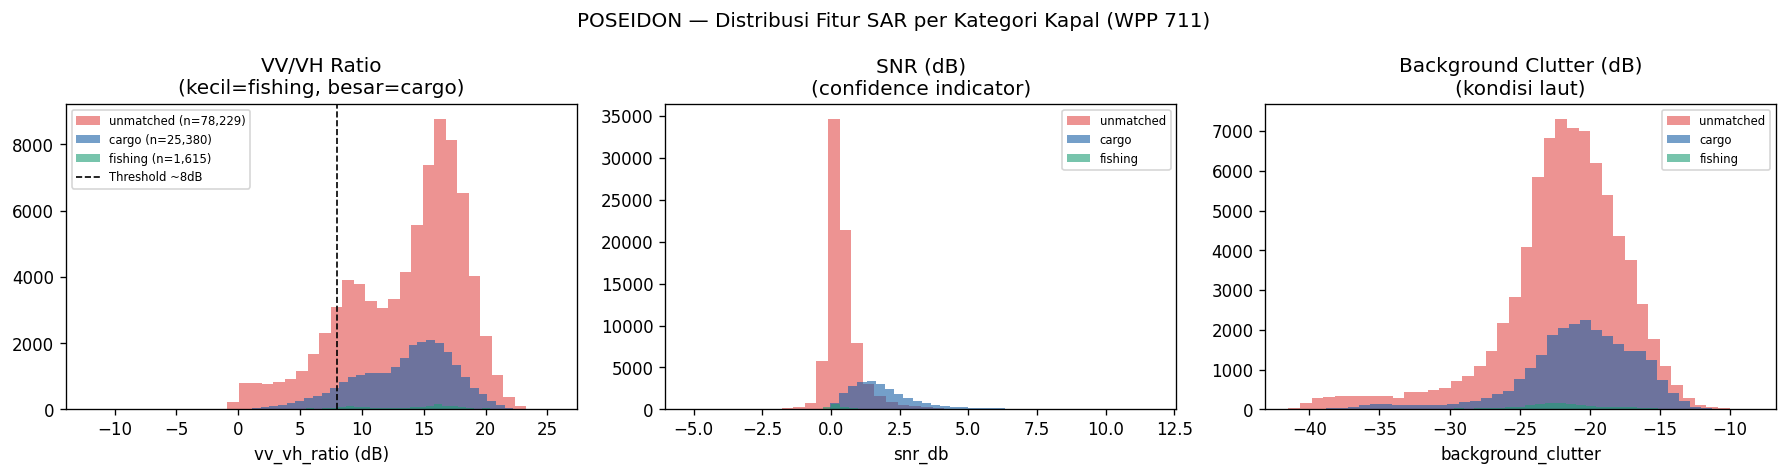

Plot validasi tersimpan


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('POSEIDON — Distribusi Fitur SAR per Kategori Kapal (WPP 711)', fontsize=12)

categories = [('unmatched', '#E24B4A'), ('cargo', '#185FA5'), ('fishing', '#1D9E75')]

ax1 = axes[0]
for cat, color in categories:
    subset = df_merged[(df_merged['matched_category'] == cat) & (df_merged['vv_vh_ratio'].notna())]['vv_vh_ratio']
    if len(subset) > 0:
        ax1.hist(subset, bins=40, alpha=0.6, color=color, label=f'{cat} (n={len(subset):,})')
ax1.axvline(x=8, color='black', linestyle='--', linewidth=1, label='Threshold ~8dB')
ax1.set_title('VV/VH Ratio\n(kecil=fishing, besar=cargo)')
ax1.set_xlabel('vv_vh_ratio (dB)')
ax1.legend(fontsize=7)

ax2 = axes[1]
for cat, color in categories:
    subset = df_merged[(df_merged['matched_category'] == cat) & (df_merged['snr_db'].notna())]['snr_db']
    if len(subset) > 0:
        ax2.hist(subset, bins=40, alpha=0.6, color=color, label=cat)
ax2.set_title('SNR (dB)\n(confidence indicator)')
ax2.set_xlabel('snr_db')
ax2.legend(fontsize=7)

ax3 = axes[2]
for cat, color in categories:
    subset = df_merged[(df_merged['matched_category'] == cat) & (df_merged['background_clutter'].notna())]['background_clutter']
    if len(subset) > 0:
        ax3.hist(subset, bins=40, alpha=0.6, color=color, label=cat)
ax3.set_title('Background Clutter (dB)\n(kondisi laut)')
ax3.set_xlabel('background_clutter')
ax3.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FOLDER_BASE + 'POSEIDON_SAR_features_validation_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot validasi tersimpan')

In [ ]:
if 'ais_matched' not in df_merged.columns:
    df_merged['ais_matched'] = (
        df_merged['matched_category'].fillna('unmatched') != 'unmatched'
    ).astype(int)

df_merged['matching_score'] = df_merged['matching_score'].fillna(0.0)

MID_TO_COUNTRY = {
    '525': 'ID', '510': 'ID', '574': 'VN',
    '412': 'CN', '413': 'CN', '414': 'CN', '477': 'HK',
    '338': 'MY', '563': 'SG', '564': 'SG',
    '567': 'TH', '572': 'PH',
    '518': 'MH', '538': 'MH',
    '511': 'PA', '370': 'PA', '371': 'PA', '372': 'PA',
    '636': 'LR', '229': 'MT', '431': 'JP', '440': 'KR', '441': 'KR',
}
FLAG_ENCODING = {
    'ID': 0, 'VN': 1, 'CN': 2, 'HK': 3, 'MY': 4, 'SG': 5, 'TH': 6, 'PH': 7,
    'MH': 8, 'PA': 9, 'LR': 10, 'MT': 11, 'JP': 12, 'KR': 13, 'OTHER': 14, 'UNKNOWN': 15,
}

def mmsi_to_flag(mmsi):
    if pd.isna(mmsi):
        return 'UNKNOWN'
    try:
        mid = str(int(mmsi))[:3]
        return MID_TO_COUNTRY.get(mid, 'OTHER')
    except Exception:
        return 'UNKNOWN'

df_merged['ais_flag_country'] = df_merged['mmsi'].apply(mmsi_to_flag)
df_merged.loc[df_merged['ais_matched'] == 0, 'ais_flag_country'] = 'UNKNOWN'
df_merged['ais_flag_country_encoded'] = (
    df_merged['ais_flag_country'].map(FLAG_ENCODING).fillna(14)
).astype(int)
df_merged['ais_vessel_type'] = df_merged['matched_category'].fillna('unmatched')

df_merged['fishing_score'] = (
    df_merged.groupby('matched_category')['fishing_score']
    .transform(lambda x: x.fillna(x.median()))
)

print('Dimensi C selesai dibuat')
print()

FITUR_MODEL_A = [
    'length_m',
    'vv_intensity_db', 'vh_intensity_db', 'vv_vh_ratio',
    'background_clutter', 'snr_db'
]

FITUR_MODEL_C = [
    'ais_matched', 'matching_score',
    'ais_flag_country_encoded', 'fishing_score'
]

FITUR_INTERPRETASI = [
    'ais_vessel_type', 'ais_flag_country'
]

FITUR_METADATA = [
    'scene_id', 'timestamp', 'lat', 'lon',
    'year', 'month', 'hour_utc', 'season',
    'presence_score', 'matched_category', 'mmsi',
    'source_yyyymm', 'pipeline_ver'
]

all_cols = FITUR_METADATA + FITUR_MODEL_A + FITUR_MODEL_C + FITUR_INTERPRETASI
all_cols = [c for c in all_cols if c in df_merged.columns]
df_final = df_merged[all_cols].copy()

output_csv = FOLDER_BASE + 'POSEIDON_WPP711_complete.csv'
df_final.to_csv(output_csv, index=False)
size_mb = os.path.getsize(output_csv) / (1024*1024)

print(f'   CSV FINAL tersimpan: {output_csv}')
print(f'   Ukuran  : {size_mb:.1f} MB')
print(f'   Baris   : {len(df_final):,}')
print(f'   Kolom   : {len(df_final.columns)}')
print()
print('Kolom yang tersimpan:')
for i, col in enumerate(df_final.columns, 1):
    print(f'  {i:02d}. {col}')
print()

Dimensi C selesai dibuat

   CSV FINAL tersimpan: /content/drive/MyDrive/DARVIN/data/gfw_sar/output/POSEIDON_WPP711_complete.csv
   Ukuran  : 49.2 MB
   Baris   : 153,523
   Kolom   : 25

Kolom yang tersimpan:
  01. scene_id
  02. timestamp
  03. lat
  04. lon
  05. year
  06. month
  07. hour_utc
  08. season
  09. presence_score
  10. matched_category
  11. mmsi
  12. source_yyyymm
  13. pipeline_ver
  14. length_m
  15. vv_intensity_db
  16. vh_intensity_db
  17. vv_vh_ratio
  18. background_clutter
  19. snr_db
  20. ais_matched
  21. matching_score
  22. ais_flag_country_encoded
  23. fishing_score
  24. ais_vessel_type
  25. ais_flag_country

